# Lab 5: Gradient Descent
- **Author:** Simón Ramírez Amaya (Based on previous material by Suraj R. Nair and Emily Aiken)
- **Date:** March 4, 2026
- **Course:** INFO 251: Applied machine learning

### Learning Objectives:
At the end of this lab, you will understand:
- What is a gradient and why it matters
- How to code component-wise and vectorized versions of the gradient descent algorithm
- How to implement gradient descent in multivariable OLS (PS4 problem 2.2)
- How the number of iterations and stopping conditions impact the convergence of gradient descent

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Background

**What is a gradient?** Let $\mathcal{L}: \mathbb{R}^{k+1} \mapsto \mathbb{R} $. The gradient of $\mathcal{L}$ is a function $\nabla \mathcal{L}: \mathbb{R}^{k+1} \mapsto \mathbb{R}^{k+1}$ defined as $$
\nabla \mathcal{L}(\beta) =
\begin{bmatrix}
\frac{\partial \mathcal{L}}{\partial \beta_0}(\beta) \\
\frac{\partial \mathcal{L}}{\partial \beta_1}(\beta) \\
\vdots \\
\frac{\partial \mathcal{L}}{\partial \beta_k}(\beta)
\end{bmatrix}
$$

### 0. Define a function

Let's use a function with two inputs, $\mathcal{L}(\beta_0,\beta_{1})=(3\beta_{0} + 4)^2+ (\beta_{1} - 3)^2 + 10$.

In [16]:
# Define the function
def L(beta0, beta1):
    return (3*beta0 + 4)**2 + (beta1-3)**2 + 10

### 1. Visualize the Function

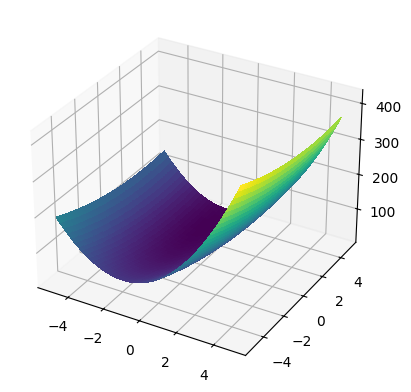

In [17]:
# Visualize the function
a = np.arange(-5, 5, 0.05)
b = np.arange(-5, 5, 0.05)

X, Y = np.meshgrid(a, b)
Z = L(X, Y)

sns.reset_orig()
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)
plt.show()

### 2. Derive the minimum 


**Question:** Calculate the *gradient* of $\mathcal{L}$: 
$$
\nabla \mathcal{L}(\beta_0,\beta_1) =
\begin{bmatrix}
\frac{\partial \mathcal{L}}{\partial \beta_0}(\beta_0,\beta_1) \\
\frac{\partial \mathcal{L}}{\partial \beta_1}(\beta_0,\beta_1) 
\end{bmatrix}
$$

**Question:** What is the minimum of this function?

**Answer**:


$$
\nabla \mathcal{L}(\beta_0,\beta_1) =
\begin{bmatrix}
\frac{\partial \mathcal{L}}{\partial \beta_0}(\beta_0,\beta_1) \\
\frac{\partial \mathcal{L}}{\partial \beta_1}(\beta_0,\beta_1)
\end{bmatrix} = \begin{bmatrix}
18 \beta_0 + 24 \\
2 \beta_1 - 6
\end{bmatrix}
$$

The minimum of this function lies at $(\beta_0^{*} = -\frac{4}{3}, \beta_1^{*} = 3)$ and $\mathcal{L}(\beta_0^{*},\beta_1^{*})$ = 10.

### 3. Finding the minimum using gradient descent

**What is gradient descent?**

- Start from an initial point $\beta^{(0)} \in \mathbb{R}^{k+1}$
- At each step t=0,1,2,... take a step in the direction opposite to the gradient:
    - $\beta^{(t+1)} =  \beta^{(t)} - r * \nabla \ \mathcal{L}(\beta^{(t)})$, where $r$ is the learning rate

Let's write a simple function to find the minimum of this function using gradient descent! In order to do this:

- fill out the gradient_descent function (scaffolding provided)
- test your function using the following inputs:
    - b0 = 5
    - b1 = 0
    - learning_rate = 0.001
    - max_iter = 5000
- visualize the function, and the optimization path (code provided below)

In [18]:
def gradient_descent(b0, b1, learning_rate, max_iter = 10000):
    """
    Inputs
    -----------
    b0: starting point for parameter beta_0
    b1: starting point for parameter beta_1
    learning_rate: R, controls the size of the update / step
    max_iter: maximum number of iterations
    
    Outputs
    b0_path: beta_0 values that are visited  
    b1_path: beta_1 values that are visited
    L_path: loss values that are visited
    """
    # Initialize your paths
    b0_path = [b0]
    b1_path = [b1]
    L_path = [L(b0, b1)]

    # Start iteration
    for i in range(max_iter):
        # Compute gradients
        gradient_b0 = 18 * b0 + 24
        gradient_b1 = 2 * b1 - 6
        # Update parameters
        b0 = b0 - learning_rate * gradient_b0
        b1 = b1 - learning_rate * gradient_b1
        # Update paths 
        b0_path.append(b0)
        b1_path.append(b1)
        L_path.append(L(b0, b1))

    return b0_path, b1_path, L_path

In [19]:
b0_path, b1_path, L_path = gradient_descent(5, 0, 0.001, max_iter = 10000)

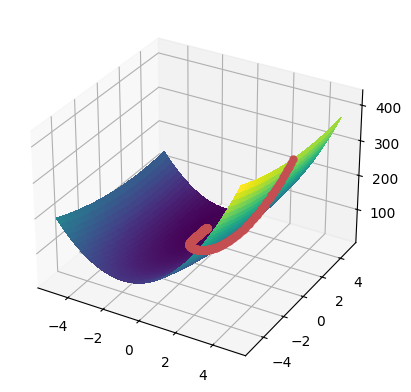

In [20]:
# Visualize the function, and the optimization path
a = np.arange(-5, 5, 0.01)
b = np.arange(-5, 5, 0.01)

X, Y = np.meshgrid(a, b)
Z = L(X, Y)

sns.reset_orig()
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)
ax.plot(b0_path, b1_path, L_path, 'r.-', linewidth=2, markersize=10, label='Optimization Path', zorder = 10)

plt.show()

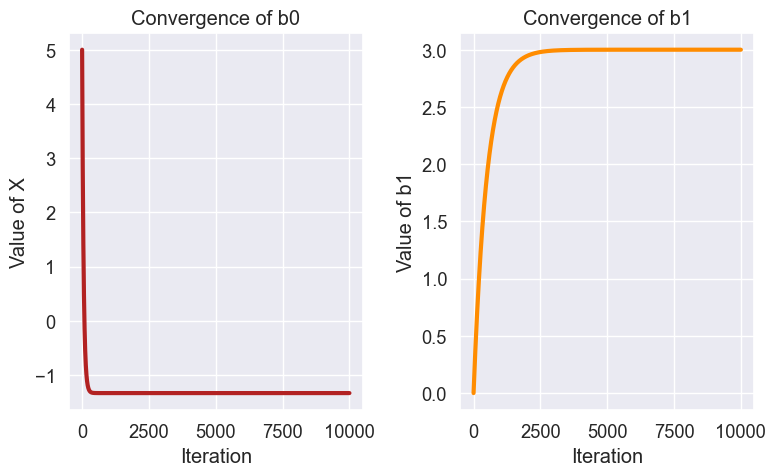

In [21]:
sns.set(font_scale=1.2)
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

ax[0].plot(range(len(b0_path)), b0_path, color='firebrick', linewidth=3)
ax[0].set_title('Convergence of b0')
ax[0].set_ylabel('Value of X')

ax[1].plot(range(len(b1_path)), b1_path, color='darkorange', linewidth=3)
ax[1].set_title('Convergence of b1')
ax[1].set_ylabel('Value of b1')

for a in range(len(ax)):
    ax[a].set_xlabel('Iteration')
    
plt.tight_layout()
plt.show()

### 4. Implement an alternative stopping condition

Modify the *gradient_descent* function to add a stopping condition. Keep max_iter as a safeguard, but stop running gradient descent if the improvements for the past *k* iterations are below some *tolerance* level.

- think carefully about how you would implement this stopping condition
- complete the *gradient_descent_w_stopping*
- test your function using the following inputs:
    - b0 = 5
    - b1 = 0
    - learning_rate = 0.001
    - compare how long it takes for convergence using stopping tolerance = [1,0.1,0.01, 0.001, 0.0001, ......]



In [8]:
def gradient_descent_w_stopping(b0, b1, learning_rate, max_iter, stopping_tolerance, k):
    """
    Inputs
    -----------
    b0: starting point for parameter beta_0
    b1: starting point for parameter beta_1
    learning_rate: R, controls the size of the update / step
    stopping_tolerance: tolerance
    k: number of steps
    
    Outputs
    b0_path: b0 coordinates that are visited  
    b1_path: b1 coordinates that are visited
    L_path: L coordinates that are visited"""
    
    # Define lists to keep track of each function value visited
    b0_path, b1_path, L_path = [b0], [b1], [L(b0, b1)]
    num_iter = 0
    for i in range(max_iter): 
                
        # Calculate the derivative at the point
        gradient_b0 = 18 * b0 + 24
        gradient_b1 = 2 * b1 - 6
        
        # Update parameters
        b0 = b0 - learning_rate * gradient_b0
        b1 = b1 - learning_rate * gradient_b1
        
        # Update paths 
        b0_path.append(b0)
        b1_path.append(b1)
        L_path.append(L(b0, b1))
        num_iter +=1

        # Stopping rule
        if len(L_path) > k:
            recent_diffs = np.abs(np.diff(L_path[-(k+1):]))
            if np.all(recent_diffs < stopping_tolerance):
                break
    
    return b0_path, b1_path, L_path, num_iter


In [22]:
for tolerance in [1,1e-1,1e-2, 1e-3, 1e-4, 1e-5, 1e-6]:
    b0_path, b1_path, L_path, num_iter = gradient_descent_w_stopping(5, 0, 0.001, max_iter =10000, stopping_tolerance=tolerance, k=10)
    print('Minimum value of L: %.5f' % L_path[-1], "Number of Iterations:", num_iter)
    print('Arguments at minimum value of L: (%.5f, %.5f)' % (b0_path[-1], b1_path[-1]))


Minimum value of L: 34.83769 Number of Iterations: 82
Arguments at minimum value of L: (0.09482, 0.45419)
Minimum value of L: 16.41346 Number of Iterations: 151
Arguments at minimum value of L: (-0.92551, 0.78266)
Minimum value of L: 12.37439 Number of Iterations: 333
Arguments at minimum value of L: (-1.31838, 1.45975)
Minimum value of L: 10.24017 Number of Iterations: 905
Arguments at minimum value of L: (-1.33333, 2.50993)
Minimum value of L: 10.02402 Number of Iterations: 1480
Arguments at minimum value of L: (-1.33333, 2.84500)
Minimum value of L: 10.00240 Number of Iterations: 2055
Arguments at minimum value of L: (-1.33333, 2.95098)
Minimum value of L: 10.00024 Number of Iterations: 2630
Arguments at minimum value of L: (-1.33333, 2.98450)


### 5. Vectorized version

Rewrite the gradient descent function. This time, instead of doing the same steps twice (once for each parameter), try to use vectorized operations whenever possible. Accordingly, your input now is a numpy araay $b$ with shape (2,).

- test your function using the same inputs:
    - \[b0,b1\] = \[5,0\]
    - learning_rate = 0.001
    - max_iter = 5000

In [24]:
 def gradient_descent(b, learning_rate, max_iter=10000):
    """
    Inputs
    -----------
    beta_init: np.array of shape (2,), initial values [b0, b1]
    learning_rate: step size
    max_iter: maximum number of iterations
    
    Outputs
    -----------
    beta_path: array of beta values visited (shape: max_iter+1, 2)
    L_path: loss values visited
    """

    # Initialize your paths
    b_path = [b]
    L_path = [L(b[0], b[1])]

    for i in range(max_iter):
        # Compute gradient
        gradient = np.array([
            18 * b[0] + 24,
            2 * b[1] - 6
        ])
        # Update parameters
        b = b - learning_rate * gradient
        # Update paths
        b_path.append(b)
        L_path.append(L(b[0], b[1]))

    return np.array(b_path), L_path

In [25]:
b_path, L_path = gradient_descent(np.array([5,0]), 0.001, max_iter = 10000)

In [26]:
b_path.shape

(10001, 2)

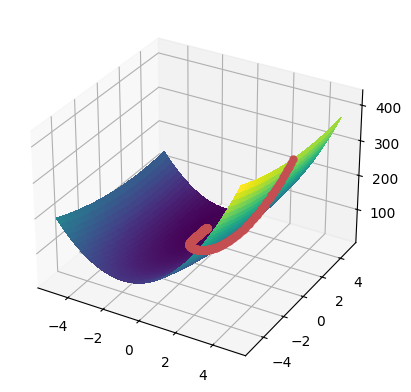

In [27]:
# Visualize the function, and the optimization path

sns.reset_orig()
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)
ax.plot(b_path[:,0], b_path[:,1], L_path, 'r.-', linewidth=2, markersize=10, label='Optimization Path', zorder = 10)

plt.show()

### 6. Vectorized multivariable OLS

What is the gradient in multivariable OLS? It is a function of your data! Recall:

$$
\mathbb{X} =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1k} \\
1 & x_{21} & x_{22} & \cdots & x_{2k} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{n1} & x_{n2} & \cdots & x_{nk}
\end{bmatrix},
\qquad
\mathbf{Y} =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix},
\qquad
\beta =
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2 \\
\vdots \\
\beta_k
\end{bmatrix}
$$

Let $y_i$ be the $i$-th element of $Y$, $x_{ij}$ the $(i,j)$-th element of $X$, 
and $\beta_j$ the $j$-th element of $\beta$.

Define the objective function:

$$
\mathcal{L}(\beta_0,\dots,\beta_k)
=
\frac{1}{2n}\sum_{i=1}^n 
\left(
y_i - \sum_{j=0}^k x_{ij} \beta_j
\right)^2.
$$

**Step 1: Differentiate with respect to $\beta_m$**

$$
\frac{\partial \mathcal{L}}{\partial \beta_m}
=
\frac{1}{2n}\sum_{i=1}^n
\frac{\partial}{\partial \beta_m}
\left(
y_i - \sum_{j=0}^k x_{ij}\beta_j
\right)^2.
$$

Let
$$
u_i(\beta)
=
y_i - \sum_{j=0}^k x_{ij}\beta_j.
$$

Using the chain rule:

$$
\frac{\partial \mathcal{L}}{\partial \beta_m}
=
\frac{1}{n}\sum_{i=1}^n
u_i(\beta)
\frac{\partial u_i(\beta)}{\partial \beta_m}.
$$

**Step 2: Differentiate the inner term**

$$
u_i(\beta)
=
y_i - \sum_{j=0}^k x_{ij}\beta_j.
$$

Since $y_i$ is constant with respect to $\beta_m$,

$$
\frac{\partial u_i}{\partial \beta_m}
=
-
\frac{\partial}{\partial \beta_m}
\left(
\sum_{j=0}^k x_{ij}\beta_j
\right).
$$

Only the term with $j=m$ depends on $\beta_m$, so

$$
\frac{\partial}{\partial \beta_m}
\left(
\sum_{j=0}^k x_{ij}\beta_j
\right)
=
x_{im}.
$$

Thus,

$$
\frac{\partial u_i}{\partial \beta_m}
=
- x_{im}.
$$

**Step 3: Substitute back**

$$
\frac{\partial L}{\partial \beta_m}
=
\frac{1}{n}\sum_{i=1}^n
u_i(\beta)(-x_{im})
=
\frac{1}{n} \sum_{i=1}^n
x_{im}
\left(
\sum_{j=0}^k x_{ij}\beta_j - y_i
\right).
$$

**Step 4: Stack**

$$
\nabla \ \mathcal{L}(\beta) =
\frac{1}{n}
\begin{bmatrix}
\sum_{i=1}^n
x_{i0}
\left(
\sum_{j=0}^k x_{ij}\beta_j - y_i
\right) \\
\sum_{i=1}^n
x_{i1}
\left(
\sum_{j=0}^k x_{ij}\beta_j - y_i
\right) \\
\vdots \\
\sum_{i=1}^n
x_{ik}
\left(
\sum_{j=0}^k x_{ij}\beta_j - y_i
\right)
\end{bmatrix} =
\frac{1}{n}
\begin{bmatrix}
\sum_{i=1}^n
1
\left(
\sum_{j=0}^k x_{ij}\beta_j - y_i
\right) \\
\sum_{i=1}^n
x_{i1}
\left(
\sum_{j=0}^k x_{ij}\beta_j - y_i
\right) \\
\vdots \\
\sum_{i=1}^n
x_{ik}
\left(
\sum_{j=0}^k x_{ij}\beta_j - y_i
\right)
\end{bmatrix}
$$

**Step 5: Find a more amenable representation**

$$
\nabla \ \mathcal{L}(\beta) =
\frac{1}{n}
\begin{bmatrix}
1 & 1 & \cdots & 1 \\
x_{11} & x_{21} & \cdots & x_{n1} \\
\vdots & \vdots & \ddots & \vdots \\
x_{1k} & x_{2k} & \cdots & x_{nk}
\end{bmatrix} 
\begin{bmatrix}
\sum_{j=0}^k x_{1j}\beta_j - y_1 \\
\sum_{j=0}^k x_{2j}\beta_j - y_2 \\
\vdots \\
\sum_{j=0}^k x_{nj}\beta_j - y_n
\end{bmatrix} = \frac{1}{n} \mathbb{X}^{T}(\mathbb{X}\beta-\mathbf{Y})
$$

In [ ]:
# Scaffolding for vectorized multivariate OLS in question 2.2 of PS4

def multivariate_ols(X, y, R=0.01, MaxIterations=1000, epsilon=1e-10):
    # Keep track of the time
    start_time = time.time()

    # Transform X and Y to arrays with the right dims and shapes
    # If X doesn't include the intercept column, add it here
    # ~3 lines

    #
    #
    #

    # Create the beta array (starting point)
    # ~1 line

    #

    # Iterate
    # ~1 line
    
    #
        
        # Compute negative of residual
        # ~1 line

        #

        # Compute the gradient
        # ~1 line

        #

        # Update parameter (don't forget the learning rate)
        # ~1 line

        #

        # Create a stopping rule (optional)
        # 5 lines

        #
        #
        #
        #
        #

    print("Time taken: {:.2f} seconds".format(time.time() - start_time))
    return beta